In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json


In [2]:
OLLAMA_API = 'http://localhost:11434/api/generate'

In [3]:
df=pd.read_csv("Womens Clothing E-Commerce Reviews.csv",index_col=0)

İçerik Bu veri seti 23.486 satır ve 10 özellik değişkeni içermektedir. Her satır bir müşteri incelemesine karşılık gelir ve şu değişkenleri içerir:

Clothing ID (Kıyafet Kimliği): İncelenen spesifik parçayı ifade eden Tam Sayı Kategorik değişken.

Age (Yaş): İncelemeyi yapan kişinin yaşını belirten Pozitif Tam Sayı değişkeni.

Title (Başlık): İncelemenin başlığı için String (metin) değişkeni.

Review Text (İnceleme Metni): İnceleme gövdesi için String (metin) değişkeni.

Rating (Derecelendirme): Müşteri tarafından verilen ürün puanını ifade eden, 1 (En Kötü) ile 5 (En İyi) arasında Pozitif Sıralı Tam Sayı değişkeni.

Recommended IND (Önerilme Durumu): Müşterinin ürünü önerip önermediğini belirten İkili (Binary) değişken; 1 önerilir, 0 önerilmez.

Positive Feedback Count (Olumlu Geri Bildirim Sayısı): Bu incelemeyi olumlu bulan diğer müşterilerin sayısını belgeleyen Pozitif Tam Sayı.

Division Name (Bölüm Adı): Ürünün üst düzey bölümünün kategorik adı.

Department Name (Departman Adı): Ürün departmanının kategorik adı.

Class Name (Sınıf Adı): Ürün sınıfının kategorik adı.

In [4]:
sutun_sozlugu = {
    'Clothing ID': 'Kiyafet_Id',
    'Age': 'Yas',
    'Title': 'Baslik',
    'Review Text': 'Inceleme Metni',
    'Rating': 'Derecelendirme',
    'Recommended IND': 'Onerilme Durumu',
    'Positive Feedback Count': 'Olumlu Geri Bildirim Sayisi',
    'Division Name': 'Bolum Adi',
    'Department Name': 'Departman Adi',
    'Class Name': 'Sinif Adi'
}

df.rename(columns=sutun_sozlugu, inplace=True)

In [5]:
df.head()


,Kiyafet_Id,Yas,Baslik,Inceleme Metni,Derecelendirme,Onerilme Durumu,Olumlu Geri Bildirim Sayisi,Bolum Adi,Departman Adi,Sinif Adi
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [6]:
df.describe()

,Kiyafet_Id,Yas,Derecelendirme,Onerilme Durumu,Olumlu Geri Bildirim Sayisi
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,918.118709,43.198544,4.196032,0.822362,2.535936
std,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,18.000000,1.000000,0.000000,0.000000
25%,861.000000,34.000000,4.000000,1.000000,0.000000
50%,936.000000,41.000000,5.000000,1.000000,1.000000
75%,1078.000000,52.000000,5.000000,1.000000,3.000000
max,1205.000000,99.000000,5.000000,1.000000,122.000000


In [7]:
df.columns

Index(['Kiyafet_Id', 'Yas', 'Baslik', 'Inceleme Metni', 'Derecelendirme',
       'Onerilme Durumu', 'Olumlu Geri Bildirim Sayisi', 'Bolum Adi',
       'Departman Adi', 'Sinif Adi'],
      dtype='object')

In [8]:
df.groupby("Sinif Adi").count().T

Sinif Adi,Blouses,Casual bottoms,Chemises,Dresses,Fine gauge,Intimates,Jackets,Jeans,Knits,Layering,Legwear,Lounge,Outerwear,Pants,Shorts,Skirts,Sleep,Sweaters,Swim,Trend
Kiyafet_Id,3097,2,1,6319,1100,154,704,1147,4843,146,165,691,328,1388,317,945,228,1428,350,119
Yas,3097,2,1,6319,1100,154,704,1147,4843,146,165,691,328,1388,317,945,228,1428,350,119
Baslik,2587,1,1,5372,927,120,598,970,3981,115,131,574,281,1157,260,796,174,1218,293,107
Inceleme Metni,2983,1,1,6145,1059,147,683,1104,4626,132,158,669,319,1350,304,903,214,1380,332,118
Derecelendirme,3097,2,1,6319,1100,154,704,1147,4843,146,165,691,328,1388,317,945,228,1428,350,119
Onerilme Durumu,3097,2,1,6319,1100,154,704,1147,4843,146,165,691,328,1388,317,945,228,1428,350,119
Olumlu Geri Bildirim Sayisi,3097,2,1,6319,1100,154,704,1147,4843,146,165,691,328,1388,317,945,228,1428,350,119
Bolum Adi,3097,2,1,6319,1100,154,704,1147,4843,146,165,691,328,1388,317,945,228,1428,350,119
Departman Adi,3097,2,1,6319,1100,154,704,1147,4843,146,165,691,328,1388,317,945,228,1428,350,119


Text(0.5, 1.0, 'Müşterilerin Yaş Dağılımı')

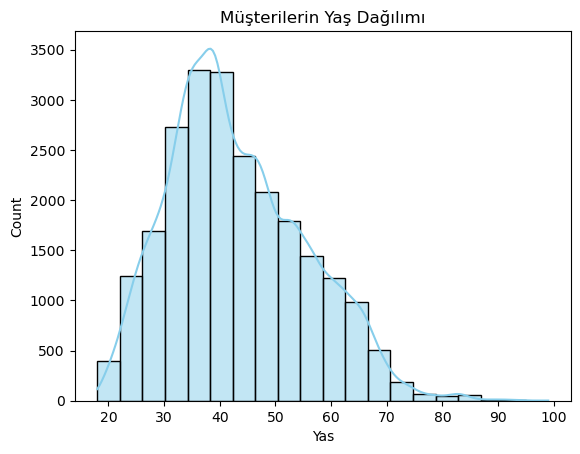

In [9]:
sns.histplot(df['Yas'], bins=20, kde=True, color='skyblue')
plt.title('Müşterilerin Yaş Dağılımı')

Text(0.5, 1.0, 'Puana Göre Önerilme')

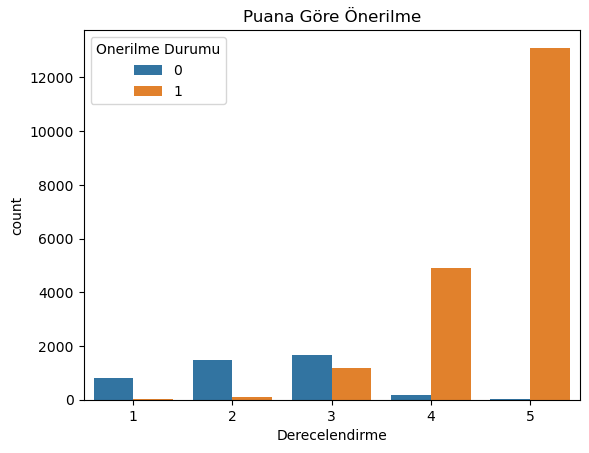

In [10]:
sns.countplot(x='Derecelendirme', hue='Onerilme Durumu', data=df)
plt.title('Puana Göre Önerilme')

Text(0.5, 1.0, 'Departman Bazlı Puanlar')

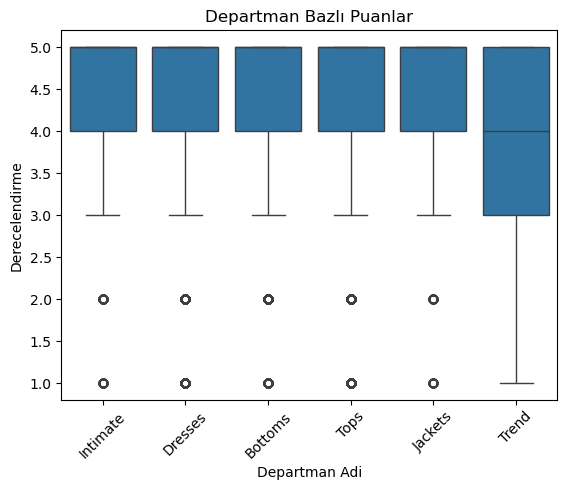

In [11]:
sns.boxplot(x='Departman Adi', y='Derecelendirme', data=df)
plt.xticks(rotation=45)
plt.title('Departman Bazlı Puanlar')

In [12]:
eksik_sayisi = df.isnull().sum()

# 2. Eksik değerlerin tüm veriye oranı (%)
eksik_orani = (df.isnull().sum() / len(df)) * 100

# 3. Okunabilir bir tablo oluşturma
eksik_veri_tablosu = pd.concat([eksik_sayisi, eksik_orani], axis=1, keys=['Eksik Sayısı', 'Eksik Oranı (%)'])

# Sadece eksik veri içeren sütunları filtreleyelim
eksik_veri_tablosu = eksik_veri_tablosu[eksik_veri_tablosu['Eksik Sayısı'] > 0].sort_values(by='Eksik Sayısı', ascending=False)

print("Eksik Veri Tablosu:")
print(eksik_veri_tablosu)

Eksik Veri Tablosu:
                Eksik Sayısı  Eksik Oranı (%)
Baslik                  3810        16.222430
Inceleme Metni           845         3.597888
Bolum Adi                 14         0.059610
Departman Adi             14         0.059610
Sinif Adi                 14         0.059610


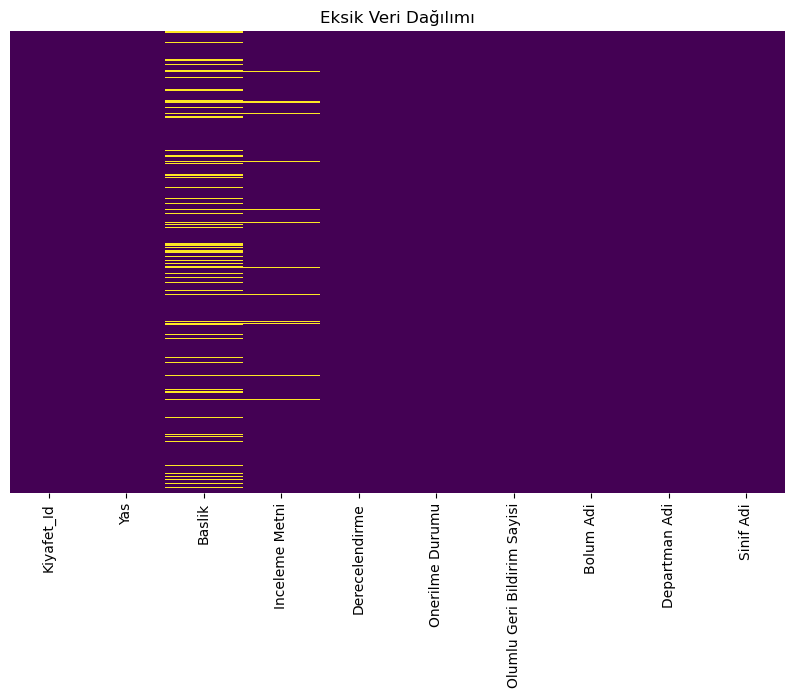

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Eksik Veri Dağılımı" )
plt.show()

-----Baslik sütunundaki eksik veriler için, Müşteri yorum yazmış ama başlık atmamış


-----İnceleme metnindeki eksik veriler,Bu müşteriler ürüne puan vermiş, ancak yazılı bir yorum yapmaya üşenmiş veya gerek duymamıştır.


In [14]:
# OLLAMA API kullanarak Eksik verilerri dolduralım

In [15]:
eksik_olanlar = df[(df['Baslik'].isnull()) & (df['Inceleme Metni'].notnull())].index

In [16]:
print(eksik_olanlar)

Index([    0,     1,    11,    30,    36,    38,    39,    40,    41,    46,
       ...
       23395, 23408, 23410, 23412, 23413, 23425, 23435, 23450, 23453, 23458],
      dtype='int64', length=2966)


In [22]:
for indeks in eksik_olanlar:
    # O satırdaki yorumu al
    yorum_metni = df.at[indeks, 'Inceleme Metni']
    
    
    # API'ye gidecek paket
    payload = {
        "model": "qwen2.5:7b",
        "prompt": f"Aşağıdaki yorum için maksimum 3 kelimelik başlık yaz. Sadece başlığı ver: {yorum_metni}",
        "stream": False
    }
    
    # İsteği at (Hata koruması yok, sorun varsa patlar)
    response = requests.post(OLLAMA_API, json=payload)
    
    # Gelen cevabı direkt DataFrame'in ilgili hücresine yaz
    yeni_baslik = response.json()['response'].strip()
    df.at[indeks, 'Baslik'] = yeni_baslik

KeyboardInterrupt: 

In [23]:
df.head()

,Kiyafet_Id,Yas,Baslik,Inceleme Metni,Derecelendirme,Onerilme Durumu,Olumlu Geri Bildirim Sayisi,Bolum Adi,Departman Adi,Sinif Adi
0,767,33,"Silky, Sexy, Comfortable",Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,Petite Dress Approval,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [24]:
eksik_olanlar = df[(df['Baslik'].isnull()) & (df['Inceleme Metni'].notnull())].index

In [25]:
print(eksik_olanlar)

Index([ 1168,  1171,  1174,  1175,  1182,  1183,  1186,  1195,  1198,  1202,
       ...
       23395, 23408, 23410, 23412, 23413, 23425, 23435, 23450, 23453, 23458],
      dtype='int64', length=2798)


In [26]:
for indeks in eksik_olanlar:
    # O satırdaki yorumu al
    yorum_metni = df.at[indeks, 'Inceleme Metni']
    
    
    # API'ye gidecek paket
    payload = {
        "model": "qwen2.5:7b",
        "prompt": f"Aşağıdaki yorum için maksimum 3 kelimelik başlık yaz. Sadece başlığı ver: {yorum_metni}",
        "stream": False
    }
    
    # İsteği at (Hata koruması yok, sorun varsa patlar)
    response = requests.post(OLLAMA_API, json=payload)
    
    # Gelen cevabı direkt DataFrame'in ilgili hücresine yaz
    yeni_baslik = response.json()['response'].strip()
    df.at[indeks, 'Baslik'] = yeni_baslik

KeyboardInterrupt: 

In [27]:
eksik_olanlar = df[(df['Baslik'].isnull()) & (df['Inceleme Metni'].notnull())].index

In [28]:
print(eksik_olanlar)

Index([ 2828,  2841,  2844,  2850,  2852,  2856,  2863,  2872,  2880,  2887,
       ...
       23395, 23408, 23410, 23412, 23413, 23425, 23435, 23450, 23453, 23458],
      dtype='int64', length=2583)


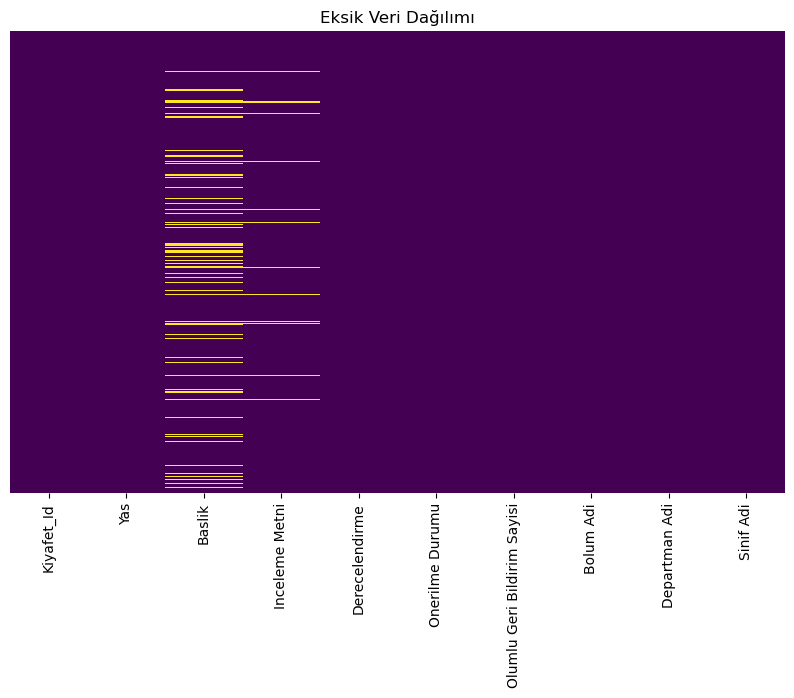

In [29]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Eksik Veri Dağılımı" )
plt.show()

In [30]:
df.head()

,Kiyafet_Id,Yas,Baslik,Inceleme Metni,Derecelendirme,Onerilme Durumu,Olumlu Geri Bildirim Sayisi,Bolum Adi,Departman Adi,Sinif Adi
0,767,33,"Silky, Sexy, Comfortable",Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,Petite Dress Approval,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


##Yaklaşık 30 dk bekleyişten sonra 500 başlık dolduruldu. 

İşlem örnek amaclı olduğu için burada sonlandırıldı.

Toplam olarak muhtemelen 2.5 saat daha beklememiz gerekecekti.

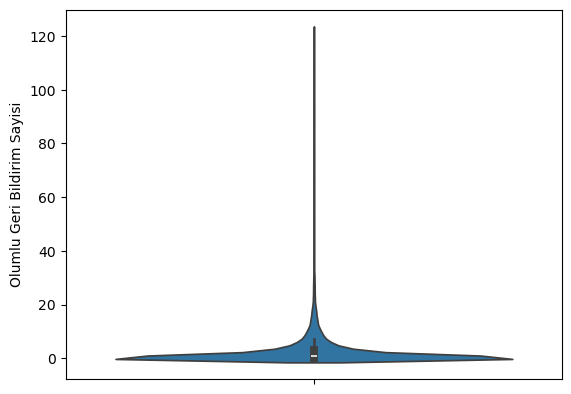

In [41]:
sns.violinplot(df['Olumlu Geri Bildirim Sayisi'])
plt.show()

In [53]:
##Yaş Gruplarını Oluşturma
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']

df['Yaş Grubu'] = pd.cut(df['Yas'], bins=bins, labels=labels)

/tmp/ipykernel_59201/3218524221.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Yaş Grubu', data=df, palette='coolwarm')


<function matplotlib.pyplot.show(close=None, block=None)>

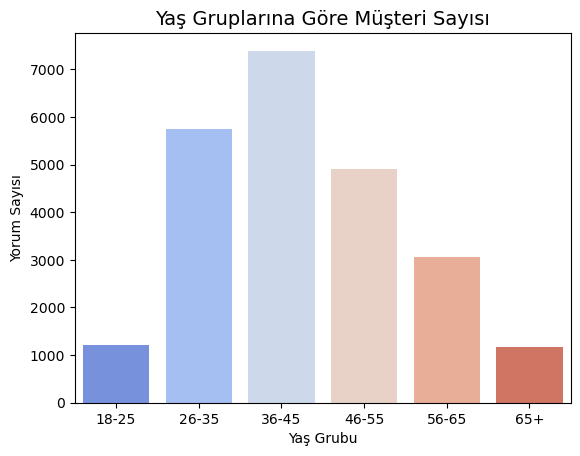

In [54]:
ax = sns.countplot(x='Yaş Grubu', data=df, palette='coolwarm')
plt.title('Yaş Gruplarına Göre Müşteri Sayısı', fontsize=14)
plt.xlabel('Yaş Grubu')
plt.ylabel('Yorum Sayısı')
plt.show

/tmp/ipykernel_59201/3683979748.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  yas_puan = df.groupby('Yaş Grubu')['Derecelendirme'].mean().reset_index()
/tmp/ipykernel_59201/3683979748.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Yaş Grubu', y='Derecelendirme', data=yas_puan, palette='viridis')


(3.5, 5.0)

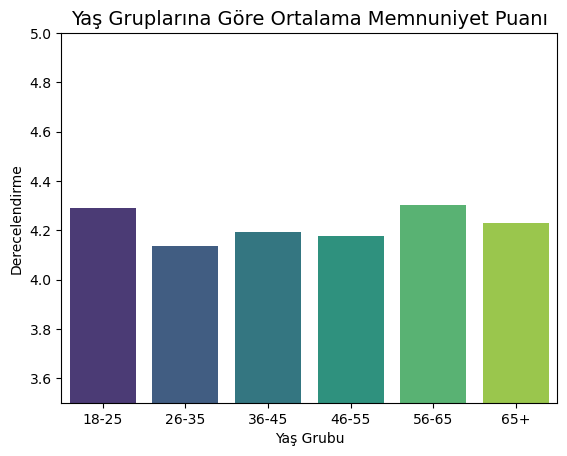

In [55]:
yas_puan = df.groupby('Yaş Grubu')['Derecelendirme'].mean().reset_index()
sns.barplot(x='Yaş Grubu', y='Derecelendirme', data=yas_puan, palette='viridis')
plt.title('Yaş Gruplarına Göre Ortalama Memnuniyet Puanı', fontsize=14)
plt.ylim(3.5, 5.0) # Farkı daha net görmek için y eksenini daralttık

Text(0.5, 1.0, 'Departman ve Yaş Grubu İlişkisi (Alışveriş Sayıları)')

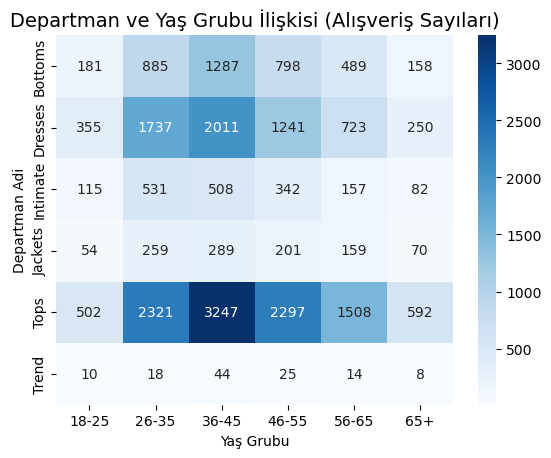

In [57]:
heatmap_data = pd.crosstab(df['Departman Adi'], df['Yaş Grubu'])
# Daha iyi okunması için normalize edelim (Sütun bazlı oranlar)
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Blues')
plt.title('Departman ve Yaş Grubu İlişkisi (Alışveriş Sayıları)', fontsize=14)

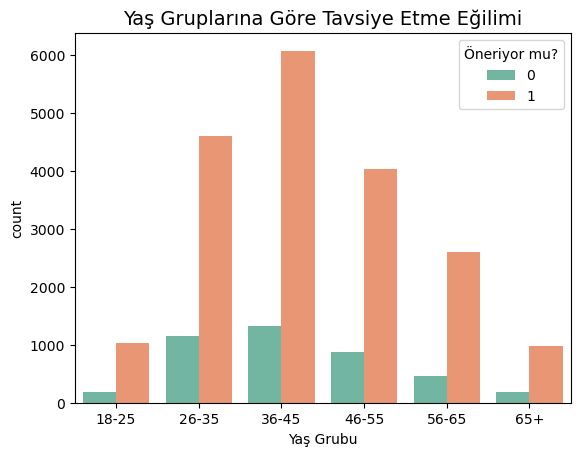

In [59]:
sns.countplot(x='Yaş Grubu', hue='Onerilme Durumu', data=df, palette='Set2')
plt.title('Yaş Gruplarına Göre Tavsiye Etme Eğilimi', fontsize=14)
plt.legend(title='Öneriyor mu?', loc='upper right')

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Kiyafet_Id                   23486 non-null  int64   
 1   Yas                          23486 non-null  int64   
 2   Baslik                       20059 non-null  object  
 3   Inceleme Metni               22641 non-null  object  
 4   Derecelendirme               23486 non-null  int64   
 5   Onerilme Durumu              23486 non-null  int64   
 6   Olumlu Geri Bildirim Sayisi  23486 non-null  int64   
 7   Bolum Adi                    23472 non-null  object  
 8   Departman Adi                23472 non-null  object  
 9   Sinif Adi                    23472 non-null  object  
 10  Yaş Grubu                    23482 non-null  category
dtypes: category(1), int64(5), object(5)
memory usage: 2.5+ MB


In [65]:
dusuk_puanlilar = df[df['Derecelendirme'] <= 2]
toplam_yorum = len(df)
sikayet_sayisi = len(dusuk_puanlilar)
oran = (sikayet_sayisi / toplam_yorum) * 100
print(f"Toplam {toplam_yorum} yorumun {sikayet_sayisi} tanesi düşük puanlı.")
print(f"Mutsuz Müşteri Oranı: %{oran:.2f}")

Toplam 23486 yorumun 2407 tanesi düşük puanlı.
Mutsuz Müşteri Oranı: %10.25


/tmp/ipykernel_59201/3878481494.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Departman Adi', data=dusuk_puanlilar,


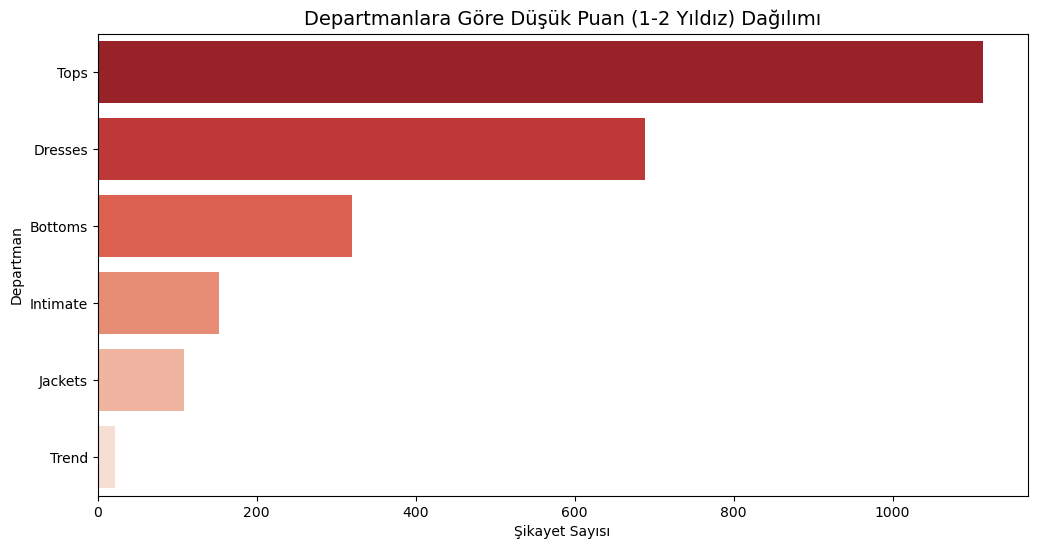

In [67]:
plt.figure(figsize=(12, 6))
sns.countplot(y='Departman Adi', data=dusuk_puanlilar, 
              order=dusuk_puanlilar['Departman Adi'].value_counts().index, 
              palette='Reds_r') # Kırmızı tonları "tehlike"yi vurgular

plt.title('Departmanlara Göre Düşük Puan (1-2 Yıldız) Dağılımı', fontsize=14)
plt.xlabel('Şikayet Sayısı')
plt.ylabel('Departman')
plt.show()

In [72]:
df.columns

Index(['Kiyafet_Id', 'Yas', 'Baslik', 'Inceleme Metni', 'Derecelendirme',
       'Onerilme Durumu', 'Olumlu Geri Bildirim Sayisi', 'Bolum Adi',
       'Departman Adi', 'Sinif Adi', 'Yaş Grubu'],
      dtype='object')

In [73]:
df['Düşük_Puan_Mi'] = df['Derecelendirme'].apply(lambda x: 1 if x <= 2 else 0)

In [74]:
urun_performansi = df.groupby('Kiyafet_Id').agg(
    Toplam_Satis=('Derecelendirme', 'count'),          # Toplam Yorum Sayısı (Satış Hacmi)
    Sikayet_Sayisi=('Düşük_Puan_Mi', 'sum'),           # 1-2 Yıldız Sayısı
    Ortalama_Puan=('Derecelendirme', 'mean'),          # Genel Puan Ortalaması
    Kategori=('Sinif Adi', 'first')                    # Ürünün kategorisi (Örn: Dress, Knits)
).reset_index()

In [79]:
urun_performansi['Sikayet_Orani'] = (urun_performansi['Sikayet_Sayisi'] / urun_performansi['Toplam_Satis']) * 100



In [82]:
sikayet_edilenler = urun_performansi[urun_performansi['Sikayet_Sayisi'] > 0]
print(sikayet_edilenler.sort_values(by='Sikayet_Orani', ascending=False).head(100))

      Kiyafet_Id  Toplam_Satis  Sikayet_Sayisi  Ortalama_Puan   Kategori  \
1176        1176             1               1       1.000000       Swim   
1158        1158             1               1       2.000000  Intimates   
982          982             1               1       2.000000    Jackets   
973          973             2               2       1.000000    Jackets   
192          192             1               1       2.000000     Lounge   
...          ...           ...             ...            ...        ...   
482          482            11               4       3.272727     Lounge   
929          929            20               7       3.200000   Sweaters   
986          986            32              11       3.468750    Jackets   
46            46             3               1       4.000000  Intimates   
363          363             3               1       3.666667   Layering   

      Sikayet_Orani  
1176     100.000000  
1158     100.000000  
982      100.000000  

<Axes: xlabel='Toplam_Satis', ylabel='Sikayet_Orani'>

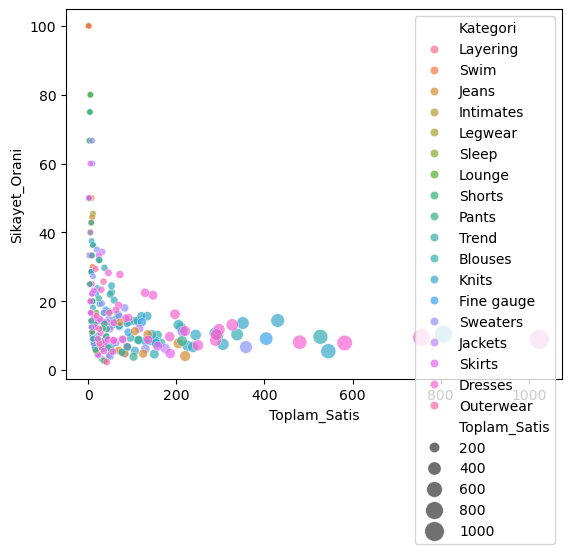

In [83]:
sns.scatterplot(data=sikayet_edilenler, 
                x='Toplam_Satis', 
                y='Sikayet_Orani', 
                hue='Kategori', # Kategorilere göre renk
                size='Toplam_Satis', # Baloncuk büyüklüğü satış hacmi
                sizes=(20, 200), 
                alpha=0.7)

Ayıkladığımız ve görüler elde ettiğimiz verimizi Sonhali.csv olarak kaydediyoruz.
İş zekası programına aktarmak için

In [84]:
df.to_csv("Sonhali.csv", index=False)
